# 08 — Bölüm 2: Fiyat EDA'sı

**Amaç:** Fiyat tahmin modelinden (Bölüm 2) **önce**, `retail_price_us`'ın dağılımını ve aday
değişkenlerle ilişkisini anlamak. Bu notebook'ta **model kurulmuyor** — sadece keşif, her adımdan sonra
bir bulgu notu.

**Veri:**
- `sets_clean.csv` (`is_analysis_ready == True`) — set özellikleri, `minifig_count`
- `brickset_prices.csv` — `retail_price_us` (inner join: **sadece fiyatı olan setler**)
- `set_colors.csv` — `n_unique_colors` (minifig parçaları dahil, bkz. notebook 07)

**Birim ve sınırlar:**
- Her satır **bir set**. Fiyatlar **nominal ABD doları** — enflasyona göre düzeltilmedi.
- Brickset eşleşmesi rastgele değil: 2015 sonrasına ve büyük/flagship setlere yığılıyor
  (notebook 05, `DATA_SOURCES.md`). Buradaki bulgular **fiyatı bilinen setler** için geçerli, tüm LEGO
  kataloğu için değil.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

PROCESSED = "../data/processed"

INK, MUTED, GRID, BASE = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"  # referans paletin ilk 3 kategorik slotu (all-pairs geçerli)
LIGHT_BLUE = "#86b6ef"


def style_ax(ax, title=None, xlabel=None, ylabel=None):
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    for side in ["left", "bottom"]:
        ax.spines[side].set_color(BASE)
    ax.tick_params(colors=MUTED, labelsize=9)
    if title:
        ax.set_title(title, color=INK, fontsize=11, loc="left")
    if xlabel:
        ax.set_xlabel(xlabel, color=MUTED)
    if ylabel:
        ax.set_ylabel(ylabel, color=MUTED)


usd = FuncFormatter(lambda v, _: f"${v:,.0f}")

## 0. Veriyi birleştir

In [2]:
sets_clean = pd.read_csv(f"{PROCESSED}/sets_clean.csv")
prices = pd.read_csv(f"{PROCESSED}/brickset_prices.csv", usecols=["brickset_set_num", "retail_price_us"])
set_colors = pd.read_csv(f"{PROCESSED}/set_colors.csv", usecols=["set_num", "n_unique_colors"])

ready = sets_clean[sets_clean["is_analysis_ready"]]
df = (
    ready.merge(prices, left_on="set_num", right_on="brickset_set_num", how="inner")
    .dropna(subset=["retail_price_us"])
    .merge(set_colors, on="set_num", how="left")
    .drop(columns="brickset_set_num")
)
assert df["set_num"].is_unique

print(f"Analiz-hazır set                 : {len(ready):,}")
print(f"retail_price_us ile eşleşen      : {len(df):,} ({len(df) / len(ready):.1%})")
print(f"  bunlardan n_unique_colors olan : {df['n_unique_colors'].notna().sum():,}")
print(f"Yıl aralığı: {df['year'].min()}–{df['year'].max()}")

Analiz-hazır set                 : 18,190
retail_price_us ile eşleşen      : 6,614 (36.4%)
  bunlardan n_unique_colors olan : 6,614
Yıl aralığı: 1991–2025


## `theme_tier` — basit tema segmenti

Bölüm 1'in (notebook 04, §4) "ilk 5 yıl → son 5 yıl medyan parça sayısı farkı" sıralaması, temaları iki
uca ayırıyordu:

- **`premium`** — Bölüm 1'de **en hızlı karmaşıklaşan** temalar: `Ultimate Collector Series` (+1.988 parça),
  `Architecture` (+1.784), `Modular Buildings` (+874), `LEGO Ideas and CUUSOO` (+679), `Technic` (+668),
  `Creator Expert` (+627). Bölüm 1'in yorumuyla bunlar büyük ölçüde yetişkin/koleksiyoner hatları.
  - **`Icons` da eklendi:** LEGO, `Creator Expert` hattını 2022'de `Icons` adıyla sürdürüyor (Modular
    Buildings da artık bu çatı altında). Eklenmeseydi 2022 sonrası Creator Expert setleri `other`'a düşer ve
    tam da 2024–2025 test yıllarında segment tanımı kayardı.
  - `Serious Play` (Bölüm 1'de 3. sırada) bilinçli olarak dışarıda: perakende tüketici ürünü değil, kurumsal
    atölye kiti; eşleşen örneklemde de yalnızca birkaç set.
  - **Dikkat — `Technic`:** Bölüm 1 onu "kitlesel olmasına rağmen hızla karmaşıklaşan" tema olarak işaretledi.
    Parça sayısı açısından premium ama fiyat bandı geniş (küçük çocuk setleri de var); §3'te bu segmentin
    içindeki dağılım bu yüzden geniş çıkabilir.
- **`mass_market`** — **durağan/kitlesel** temalar: Bölüm 1'in en durağan tablosundan `Basic Set` (−0,5),
  `Ninjago` (+5,5), `Police` (+6), `Mickey & Friends` (+2); bunlara ek olarak çocuk odaklı büyük hatlar
  `City`, `Friends` ve `Duplo`. Not: `City` ve `Friends` Bölüm 1'in durağan *tablosunda* yok (tablo ≥10 farklı
  yıl ve örtüşmeyen pencereler şartı arıyordu); `Friends`'in yatay seyri Bölüm 1'in tema grafiğinde
  görülüyordu, `City` ise hedef kitlesi (çocuk, oyun seti) nedeniyle bu gruba alındı.
- **`other`** — geri kalan her şey (Star Wars, Harry Potter, Creator 3-in-1, lisanslı temaların çoğu…).

Bu bilinçli olarak **kaba** bir ayrım: amacı modele yüzlerce tema kategorisi yerine yorumlanabilir tek bir
segment sinyali vermek. Sınırdaki temalar (ör. Star Wars'un içindeki UCS olmayan büyük setler) `other`'da kalıyor.

In [3]:
PREMIUM = ["Ultimate Collector Series", "Architecture", "Modular Buildings", "LEGO Ideas and CUUSOO",
           "Technic", "Creator Expert", "Icons"]
MASS_MARKET = ["City", "Friends", "Ninjago", "Basic Set", "Duplo", "Police", "Mickey & Friends"]
TIERS = ["premium", "mass_market", "other"]
TIER_COLORS = dict(zip(TIERS, [BLUE, ORANGE, AQUA]))

df["theme_tier"] = np.select(
    [df["theme_name"].isin(PREMIUM), df["theme_name"].isin(MASS_MARKET)], ["premium", "mass_market"], "other"
)
df["theme_tier"] = pd.Categorical(df["theme_tier"], categories=TIERS, ordered=False)

missing = set(PREMIUM + MASS_MARKET) - set(df["theme_name"])
print(f"Listede olup eşleşen örneklemde hiç seti olmayan tema: {sorted(missing) or 'yok'}")
(
    df.groupby("theme_tier", observed=True)
    .agg(set_sayisi=("set_num", "size"), tema_sayisi=("theme_name", "nunique"),
         medyan_fiyat=("retail_price_us", "median"), medyan_parca=("num_parts", "median"))
    .assign(pay=lambda t: (t["set_sayisi"] / t["set_sayisi"].sum() * 100).round(1))
)

Listede olup eşleşen örneklemde hiç seti olmayan tema: yok


,set_sayisi,tema_sayisi,medyan_fiyat,medyan_parca,pay
theme_tier,,,,,
premium,514,7,99.99,1083.5,7.8
mass_market,1187,7,29.99,196.0,17.9
other,4913,218,24.99,206.0,74.3


In [4]:
df.loc[df["theme_tier"] != "other"].groupby(["theme_tier", "theme_name"], observed=True).size().rename("set_sayisi").to_frame()

set_sayisi
theme_tier  theme_name                           
premium     Architecture                       42
            Creator Expert                     34
            Icons                              59
            LEGO Ideas and CUUSOO              71
            Modular Buildings                  20
            Technic                           249
            Ultimate Collector Series          39
mass_market Basic Set                          75
            City                              142
            Duplo                              52
            Friends                           449
            Mickey & Friends                   18
            Ninjago                           343
            Police                            108

## 1. Dağılım kontrolü: `retail_price_us` ve `num_parts`

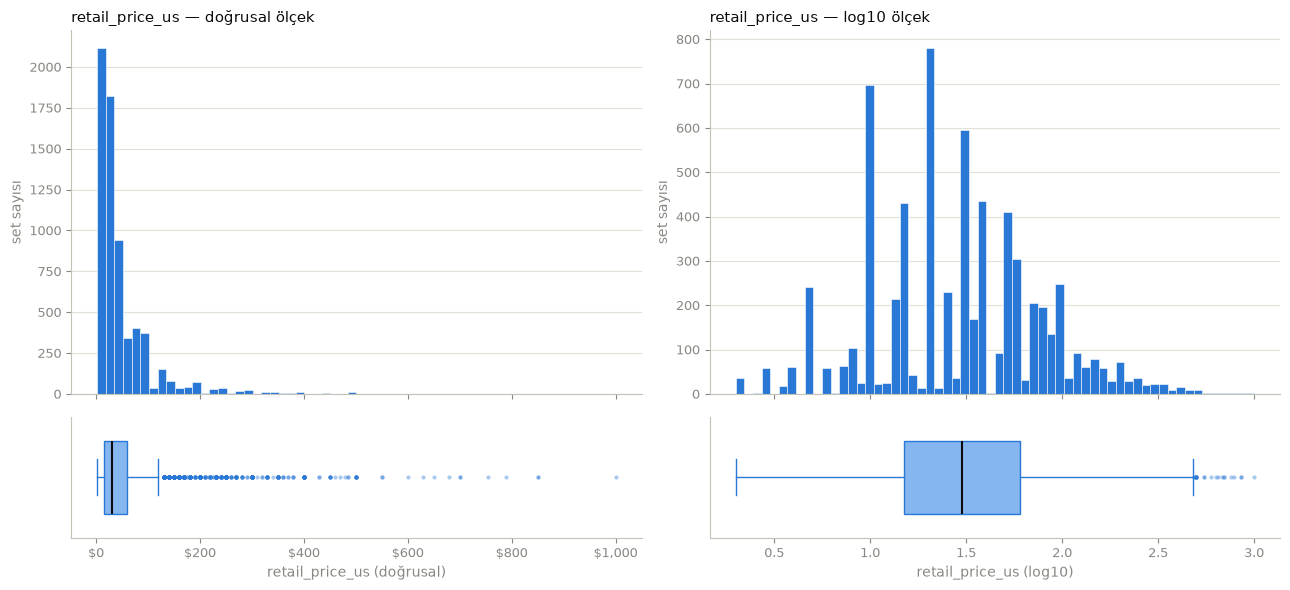

skewness            4.56
log10_skewness      0.12
min                 1.99
medyan             29.99
ortalama           48.74
max               999.99
dtype: float64

In [5]:
def distribution_panel(series, label, fmt=None):
    fig, axes = plt.subplots(2, 2, figsize=(13, 6), gridspec_kw={"height_ratios": [3, 1]}, sharex="col")
    for col, (values, scale) in enumerate([(series, "doğrusal"), (np.log10(series), "log10")]):
        axes[0, col].hist(values, bins=60, color=BLUE, edgecolor="white", linewidth=0.4)
        style_ax(axes[0, col], title=f"{label} — {scale} ölçek", ylabel="set sayısı")
        axes[1, col].boxplot(values, orientation="horizontal", widths=0.6, patch_artist=True,
                             boxprops=dict(facecolor=LIGHT_BLUE, edgecolor=BLUE),
                             medianprops=dict(color=INK, linewidth=1.5),
                             whiskerprops=dict(color=BLUE), capprops=dict(color=BLUE),
                             flierprops=dict(marker="o", markersize=3, markerfacecolor=BLUE, markeredgecolor="none", alpha=0.4))
        axes[1, col].set_yticks([])
        style_ax(axes[1, col], xlabel=f"{label} ({scale})")
    if fmt:
        axes[1, 0].xaxis.set_major_formatter(fmt)
    fig.tight_layout()
    plt.show()
    return pd.Series({
        "skewness": series.skew(), "log10_skewness": np.log10(series).skew(),
        "min": series.min(), "medyan": series.median(), "ortalama": series.mean(), "max": series.max(),
    })


price_stats = distribution_panel(df["retail_price_us"], "retail_price_us", usd)
price_stats.round(2)

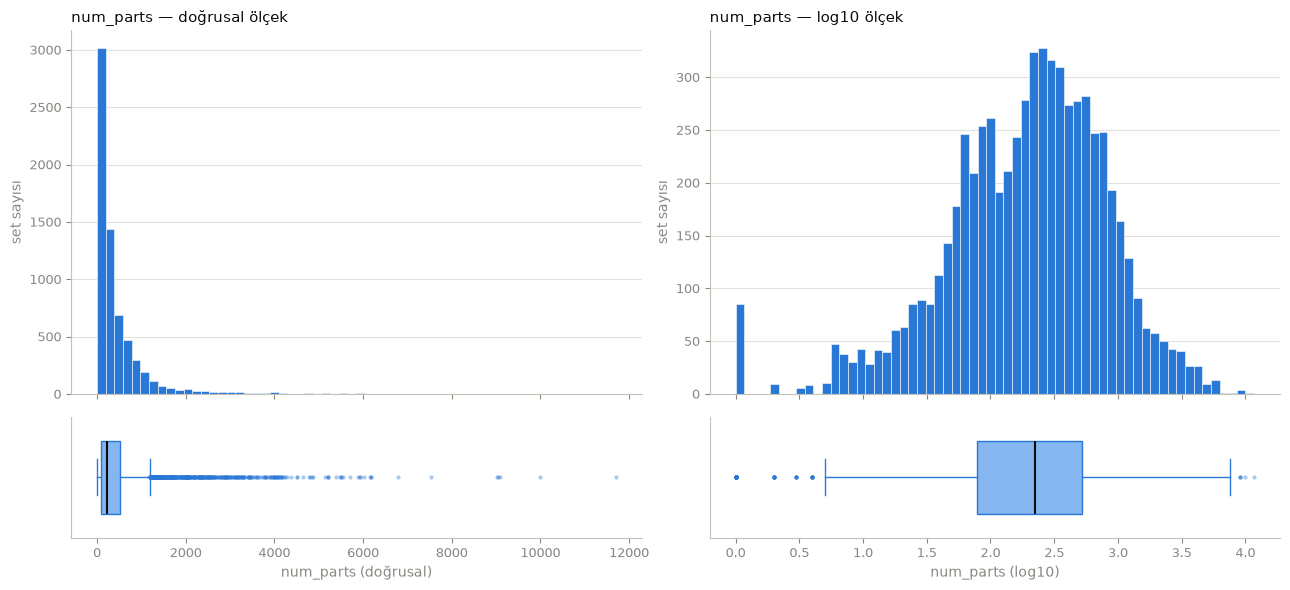

log10(num_parts) skewness: -0.72


,tüm analiz-hazır setler (Bölüm 1),fiyatı bilinen alt küme
skewness,6.71,4.91
medyan,64.00,224.00
ortalama,234.72,445.39


In [6]:
parts_stats = distribution_panel(df["num_parts"], "num_parts")
parts_compare = pd.DataFrame({
    "tüm analiz-hazır setler (Bölüm 1)": [ready["num_parts"].skew(), ready["num_parts"].median(), ready["num_parts"].mean()],
    "fiyatı bilinen alt küme": [df["num_parts"].skew(), df["num_parts"].median(), df["num_parts"].mean()],
}, index=["skewness", "medyan", "ortalama"])
print(f"log10(num_parts) skewness: {parts_stats['log10_skewness']:.2f}")
parts_compare.round(2)

**Bulgu:**
- **`retail_price_us` çok güçlü sağa çarpık:** skewness 4,56; medyan $29,99, ortalama $48,74, maksimum $999,99.
  **log10 dönüşümünden sonra neredeyse simetrik** (skewness 0,12) → modelde hedef değişken olarak **log fiyat** kullanılmalı.
- Log histogramdaki keskin dikenler gürültü değil, **LEGO'nun fiyat noktaları** ($9,99, $19,99, $29,99, $49,99…).
  Fiyat sürekli değil kademeli bir değişken; hata metriklerini yorumlarken akılda tutulmalı.
- **`num_parts` bu alt kümede farklı davranıyor:** medyan **224** parça (tüm analiz-hazır setlerde 64 — 3,5 kat),
  ortalama 445 (235). Skewness 4,91 (Bölüm 1'de 6,71) — hâlâ çok çarpık; log10 sonrası −0,72 (hafif sola, kabul
  edilebilir). Bu, Brickset eşleşmesinin büyük setlere yığıldığını (notebook 05) doğruluyor: Bölüm 1'deki "tipik
  set" ile fiyatı bilinen "tipik set" aynı değil.

## 2. Yıl kırılımı

**Kapsam notu:** Fiyat trendi **2015–2025** için çiziliyor. Eşleşen setlerin çoğu bu dönemde ve her yıl
en az ~350 set var; 2005 öncesi yıllar tek haneli set sayılarına düşüyor. Ama veri bu döneme tamamen
yığılı **değil** — aşağıdaki tablo 2015 öncesinin payını da gösteriyor (bu, §7'deki bölme için önemli).

In [7]:
counts = df["year"].value_counts().sort_index()
periods = pd.cut(df["year"], bins=[0, 2004, 2014, 2025], labels=["≤2004", "2005–2014", "2015–2025"])
period_table = periods.value_counts().sort_index().to_frame("set_sayisi").assign(pay=lambda t: (t["set_sayisi"] / len(df) * 100).round(1))
period_table

,set_sayisi,pay
year,,
≤2004,51,0.8
2005–2014,2215,33.5
2015–2025,4348,65.7


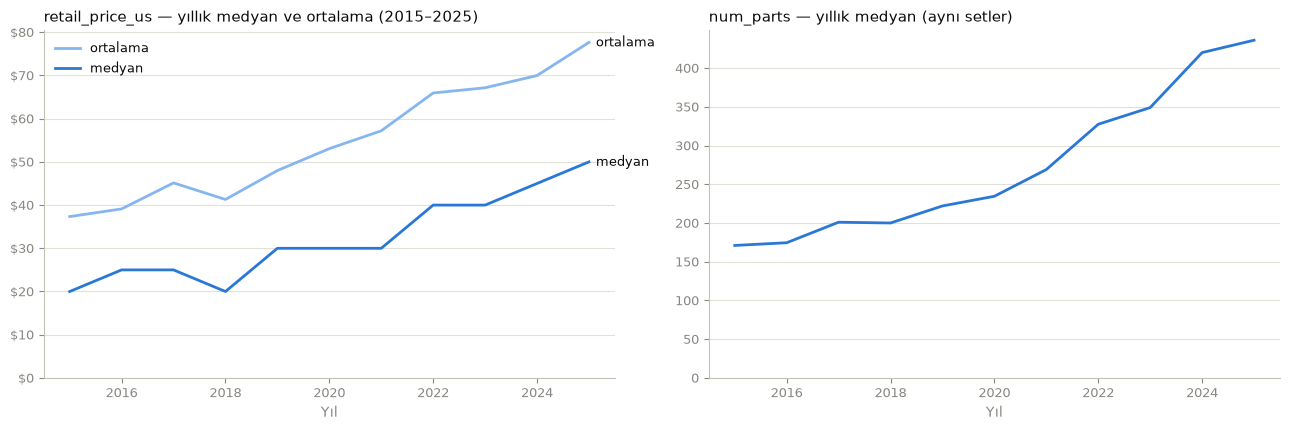

,n,medyan_fiyat,ortalama_fiyat,medyan_parca,medyan_fiyat_parca_basina
year,,,,,
2015,378,19.99,37.33,171.0,0.11
2016,390,24.99,39.11,174.5,0.11
2017,365,24.99,45.12,201.0,0.11
2018,385,19.99,41.29,200.0,0.11
2019,350,29.99,47.98,222.0,0.11
2020,388,29.99,53.06,234.5,0.12
2021,419,29.99,57.18,269.0,0.11
2022,382,39.99,65.93,327.5,0.11
2023,405,39.99,67.14,349.0,0.11


In [8]:
recent = df[df["year"].between(2015, 2025)]
yearly = recent.groupby("year").agg(
    n=("set_num", "size"),
    medyan_fiyat=("retail_price_us", "median"),
    ortalama_fiyat=("retail_price_us", "mean"),
    medyan_parca=("num_parts", "median"),
    medyan_fiyat_parca_basina=("retail_price_us", lambda p: (p / recent.loc[p.index, "num_parts"]).median()),
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
ax = axes[0]
ax.plot(yearly.index, yearly["ortalama_fiyat"], color=LIGHT_BLUE, linewidth=2, label="ortalama")
ax.plot(yearly.index, yearly["medyan_fiyat"], color=BLUE, linewidth=2, label="medyan")
for name, color in [("ortalama", LIGHT_BLUE), ("medyan", BLUE)]:
    col = "ortalama_fiyat" if name == "ortalama" else "medyan_fiyat"
    ax.annotate(name, (2025, yearly.loc[2025, col]), xytext=(5, 0), textcoords="offset points", color=INK, fontsize=9, va="center")
ax.yaxis.set_major_formatter(usd)
ax.set_ylim(bottom=0)
style_ax(ax, title="retail_price_us — yıllık medyan ve ortalama (2015–2025)", xlabel="Yıl")
ax.legend(frameon=False, fontsize=9, labelcolor=INK, loc="upper left")

ax = axes[1]
ax.plot(yearly.index, yearly["medyan_parca"], color=BLUE, linewidth=2)
ax.set_ylim(bottom=0)
style_ax(ax, title="num_parts — yıllık medyan (aynı setler)", xlabel="Yıl")
fig.tight_layout()
plt.show()

yearly.round(2)

**Bulgu:**
- 2015–2025 arasında **medyan fiyat $19,99 → $49,99** (2,5 kat), ortalama $37 → $78.
- Ama aynı setlerde **medyan parça sayısı da 171 → 436** (2,5 kat) ve **medyan parça başına fiyat her yıl
  $0,10–0,12 bandında sabit.** Yani nominal fiyat artışının neredeyse tamamı "setler büyüyor" etkisi; parça
  başına nominal fiyat yerinde saydığı için, enflasyon düşünülünce **reel parça başı fiyat düşmüş** bile.
- Sonuç: `year` fiyatla ilişkili görünecek (Spearman 0,27) ama bu etkinin büyük kısmı `num_parts` üzerinden
  geliyor; modelde yıl tek başına güçlü bir sinyal değil.
- Kapsam: eşleşen setlerin %65,7'si 2015–2025'te, **%33,5'i 2005–2014'te**, %0,8'i 2004 ve öncesinde.

## 3. Tema kırılımı: `theme_tier`

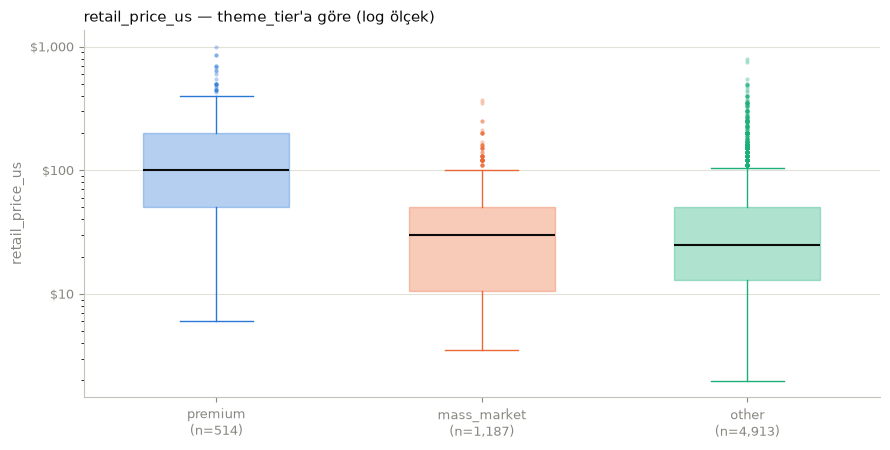

,count,mean,std,min,25%,50%,75%,90%,max
theme_tier,,,,,,,,,
premium,514.0,139.54,134.73,5.99,49.99,99.99,199.99,299.99,999.99
mass_market,1187.0,37.73,36.29,3.49,10.49,29.99,49.99,79.99,369.99
other,4913.0,41.89,51.85,1.99,12.99,24.99,49.99,89.99,789.99


In [9]:
fig, ax = plt.subplots(figsize=(9, 4.6))
data = [df.loc[df["theme_tier"] == t, "retail_price_us"] for t in TIERS]
bp = ax.boxplot(data, widths=0.55, patch_artist=True,
                medianprops=dict(color=INK, linewidth=1.5),
                flierprops=dict(marker="o", markersize=3, markeredgecolor="none", alpha=0.35))
for patch, flier, whisk_pair, tier in zip(bp["boxes"], bp["fliers"], zip(bp["whiskers"][::2], bp["whiskers"][1::2]), TIERS):
    patch.set_facecolor(TIER_COLORS[tier]); patch.set_alpha(0.35); patch.set_edgecolor(TIER_COLORS[tier])
    flier.set_markerfacecolor(TIER_COLORS[tier])
    for w in whisk_pair:
        w.set_color(TIER_COLORS[tier])
for cap, tier in zip(bp["caps"], np.repeat(TIERS, 2)):
    cap.set_color(TIER_COLORS[tier])
ax.set_xticks(range(1, len(TIERS) + 1))
ax.set_xticklabels([f"{t}\n(n={len(d):,})" for t, d in zip(TIERS, data)], color=INK)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(usd)
style_ax(ax, title="retail_price_us — theme_tier'a göre (log ölçek)", ylabel="retail_price_us")
fig.tight_layout()
plt.show()

df.groupby("theme_tier", observed=True)["retail_price_us"].describe(percentiles=[0.25, 0.5, 0.75, 0.9]).round(2)

In [10]:
# Segment farkı sadece set büyüklüğü farkı mı? Parça başına fiyat ve aynı büyüklük dilimi içinde medyan fiyat
size_bins = [0, 100, 500, float("inf")]
size_labels = ["≤100 parça", "101–500 parça", ">500 parça"]
df["size_tier"] = pd.cut(df["num_parts"], bins=size_bins, labels=size_labels)
df["price_per_part"] = df["retail_price_us"] / df["num_parts"]

within_size = df.pivot_table(index="size_tier", columns="theme_tier", values="retail_price_us", aggfunc="median", observed=True)
within_size_n = df.pivot_table(index="size_tier", columns="theme_tier", values="set_num", aggfunc="size", observed=True)
print("Medyan parça başına fiyat ($):")
print(df.groupby("theme_tier", observed=True)["price_per_part"].median().round(3).to_string())
print("\nAynı büyüklük dilimi içinde medyan fiyat ($) — parantez içi set sayısı:")
within_size.round(2).astype(str) + " (" + within_size_n.astype(str) + ")"

Medyan parça başına fiyat ($):
theme_tier
premium        0.096
mass_market    0.120
other          0.115

Aynı büyüklük dilimi içinde medyan fiyat ($) — parantez içi set sayısı:


theme_tier,premium,mass_market,other
size_tier,,,
≤100 parça,19.99 (9),9.99 (438),9.99 (1605)
101–500 parça,24.99 (125),29.99 (510),26.99 (2187)
>500 parça,139.99 (380),79.99 (239),79.99 (1121)


**Bulgu:**
- **`premium` açıkça ayrışıyor:** medyan $99,99 (`mass_market` $29,99, `other` $24,99). Ama premium'un **parça
  başına fiyatı en düşük** ($0,096; diğerleri $0,12 / $0,115) — premium setler pahalı çünkü **büyükler** (medyan
  1.084 parça).
- **`mass_market` ile `other` neredeyse ayırt edilemiyor:** aynı büyüklük dilimlerinde medyan fiyatları aynı
  ($9,99 / ~$27–30 / $79,99). Bu ayrım fiyat için zayıf bir sinyal.
- **Gerçek segment etkisi büyük setlerde:** >500 parçalı setlerde premium medyanı **$139,99**, diğerleri $79,99 —
  aynı büyüklükte premium etiketi ~1,75 kat fiyat taşıyor (UCS/Modular/Ideas'ın koleksiyoner fiyatlaması).
  ≤100 parçalı premium setler yalnızca 9 tane, yorumlanmamalı.
- Sonuç: `theme_tier` bilgisinin çoğu `num_parts` ile örtüşüyor; asıl katkısı **büyük setlerde premium primi** →
  modelde `num_parts × premium` etkileşimi düşünülebilir.

## 4. Parça sayısı ilişkisi: `num_parts` ~ `retail_price_us`

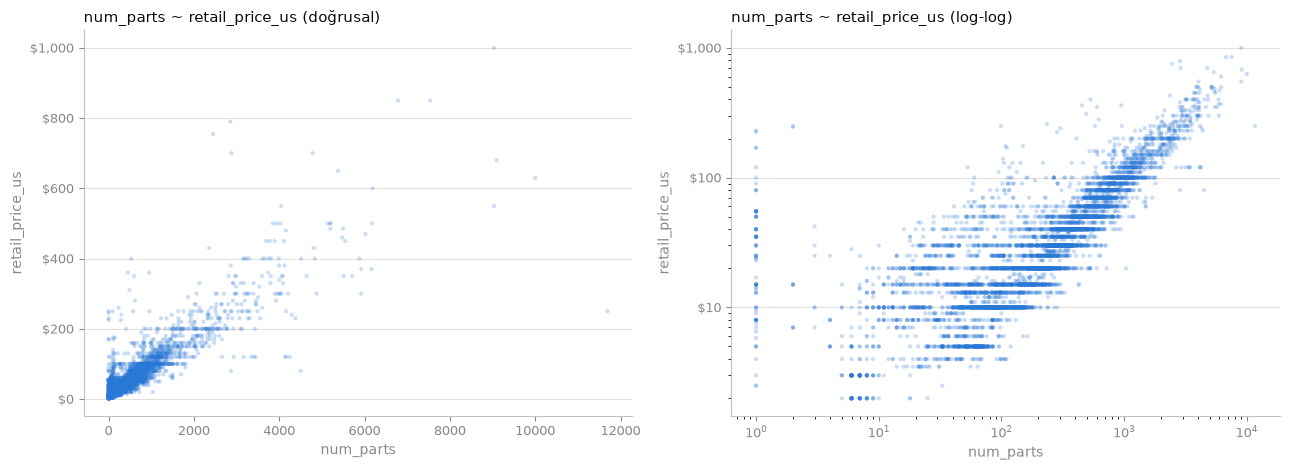

log-log eğim (esneklik): 0.53 — parça sayısı %10 artınca fiyat ~%5.2 artıyor


n                  6614.000
pearson               0.890
spearman              0.846
pearson_log_log       0.773
dtype: float64

In [11]:
def correlations(x, y):
    both = pd.concat([x, y], axis=1).dropna()
    xs, ys = both.iloc[:, 0], both.iloc[:, 1]
    out = {"n": len(both), "pearson": xs.corr(ys), "spearman": xs.corr(ys, method="spearman")}
    if (xs > 0).all():
        out["pearson_log_log"] = np.log10(xs).corr(np.log10(ys))
    else:
        out["pearson_log1p_x_log_y"] = np.log1p(xs).corr(np.log10(ys))
    return pd.Series(out)


fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, log in zip(axes, [False, True]):
    ax.scatter(df["num_parts"], df["retail_price_us"], s=9, color=BLUE, alpha=0.25, edgecolors="none")
    if log:
        ax.set_xscale("log"); ax.set_yscale("log")
    ax.yaxis.set_major_formatter(usd)
    style_ax(ax, title=f"num_parts ~ retail_price_us ({'log-log' if log else 'doğrusal'})", xlabel="num_parts", ylabel="retail_price_us")
fig.tight_layout()
plt.show()

parts_corr = correlations(df["num_parts"], df["retail_price_us"])
slope, intercept = np.polyfit(np.log10(df["num_parts"]), np.log10(df["retail_price_us"]), 1)
print(f"log-log eğim (esneklik): {slope:.2f} — parça sayısı %10 artınca fiyat ~%{(1.1 ** slope - 1) * 100:.1f} artıyor")
parts_corr.round(3)

**Bulgu:**
- **En güçlü ilişki:** Spearman **0,846**, log-log Pearson **0,773**. Ham Pearson (0,890) en yüksek görünse de
  birkaç çok büyük/pahalı set tarafından şişiriliyor — çarpık iki değişken için log-log ölçümü daha dürüst.
- Log-log saçılım doğrusal görünümlü ve **eğim 0,53**: fiyat parça sayısıyla orantılı değil, **azalan oranda** artıyor
  (parça %10 artınca fiyat ~%5,2). Büyük setlerde parça başına fiyat düşüyor (bkz. §3'teki premium bulgusu).
- Sonuç: log(fiyat) ~ log(parça) doğrusal ilişkisi modelin omurgası olmaya aday.

## 5. Minifig ilişkisi: `minifig_count` ~ `retail_price_us`

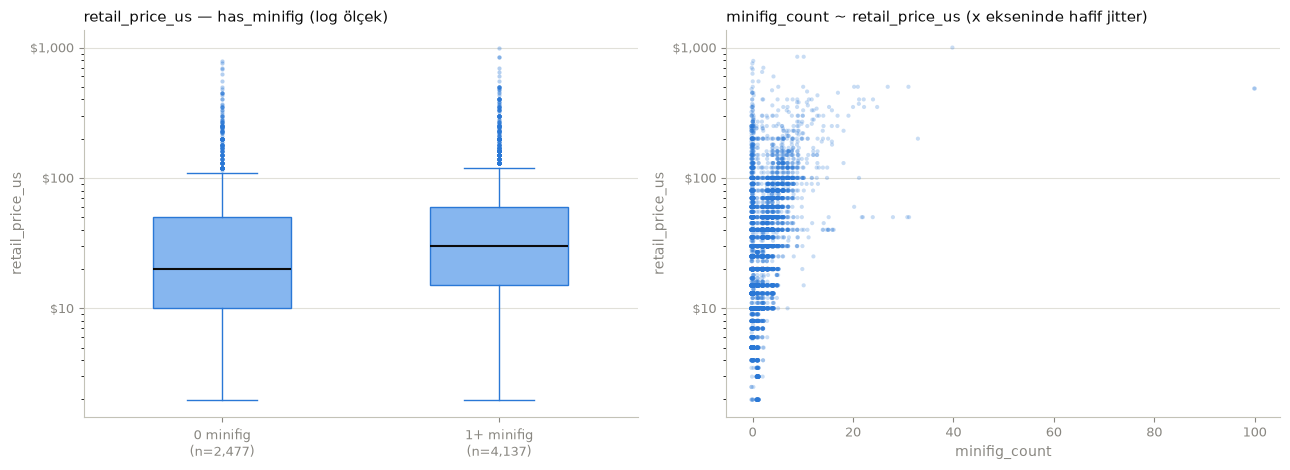

             size  median   mean
has_minifig                     
0 minifig    2477   19.99  42.46
1+ minifig   4137   29.99  52.49



n                        6614.000
pearson                     0.421
spearman                    0.414
pearson_log1p_x_log_y       0.410
dtype: float64

In [12]:
df["has_minifig"] = np.where(df["minifig_count"] > 0, "1+ minifig", "0 minifig")
groups = ["0 minifig", "1+ minifig"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
ax = axes[0]
data = [df.loc[df["has_minifig"] == g, "retail_price_us"] for g in groups]
ax.boxplot(data, widths=0.5, patch_artist=True,
           boxprops=dict(facecolor=LIGHT_BLUE, edgecolor=BLUE), medianprops=dict(color=INK, linewidth=1.5),
           whiskerprops=dict(color=BLUE), capprops=dict(color=BLUE),
           flierprops=dict(marker="o", markersize=3, markerfacecolor=BLUE, markeredgecolor="none", alpha=0.35))
ax.set_xticks([1, 2])
ax.set_xticklabels([f"{g}\n(n={len(d):,})" for g, d in zip(groups, data)], color=INK)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(usd)
style_ax(ax, title="retail_price_us — has_minifig (log ölçek)", ylabel="retail_price_us")

ax = axes[1]
jitter = np.random.default_rng(42).uniform(-0.25, 0.25, len(df))
ax.scatter(df["minifig_count"] + jitter, df["retail_price_us"], s=9, color=BLUE, alpha=0.25, edgecolors="none")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(usd)
style_ax(ax, title="minifig_count ~ retail_price_us (x ekseninde hafif jitter)", xlabel="minifig_count", ylabel="retail_price_us")
fig.tight_layout()
plt.show()

print(df.groupby("has_minifig")["retail_price_us"].agg(["size", "median", "mean"]).round(2).to_string())
print()
fig_corr = correlations(df["minifig_count"], df["retail_price_us"])
fig_corr.round(3)

In [13]:
# Minifigli setler sadece daha büyük oldukları için mi pahalı? Aynı büyüklük dilimi içinde karşılaştır.
fig_within = df.pivot_table(index="size_tier", columns="has_minifig", values="retail_price_us", aggfunc="median", observed=True)
fig_within["oran (1+ / 0)"] = fig_within["1+ minifig"] / fig_within["0 minifig"]
fig_within["n (0 / 1+)"] = (
    df.pivot_table(index="size_tier", columns="has_minifig", values="set_num", aggfunc="size", observed=True)
    .astype(str).agg(" / ".join, axis=1)
)
print(f"minifig_count ~ num_parts Spearman: {df['minifig_count'].corr(df['num_parts'], method='spearman'):.3f}")
fig_within.round(2)

minifig_count ~ num_parts Spearman: 0.451


has_minifig,0 minifig,1+ minifig,oran (1+ / 0),n (0 / 1+)
size_tier,,,,
≤100 parça,12.99,9.99,0.77,1151 / 901
101–500 parça,19.99,29.99,1.50,804 / 2018
>500 parça,79.99,89.99,1.13,522 / 1218


**Bulgu:**
- **Orta-zayıf ilişki:** Spearman **0,414**. Minifigli setlerin medyanı $29,99, minifigsizlerin $19,99 — ama bunun
  bir kısmı büyüklük: `minifig_count` ile `num_parts` arasında Spearman 0,45.
- **Aynı büyüklük dilimi içinde etki yön değiştiriyor:** 101–500 parçada minifigli setler **1,5 kat** pahalı (gerçek ek
  sinyal), >500 parçada 1,13 kat, ≤100 parçada ise **tersine 0,77 kat** (küçük minifig paketleri/polybag'ler ucuz).
- Sonuç: `minifig_count`'ın sayısal hali tek başına gürültülü; etki doğrusal değil ve büyüklüğe bağlı.
  `has_minifig` (ikili) + büyüklükle etkileşim daha anlamlı bir özellik olabilir.

## 6. Renk ilişkisi: `n_unique_colors` ~ `retail_price_us`

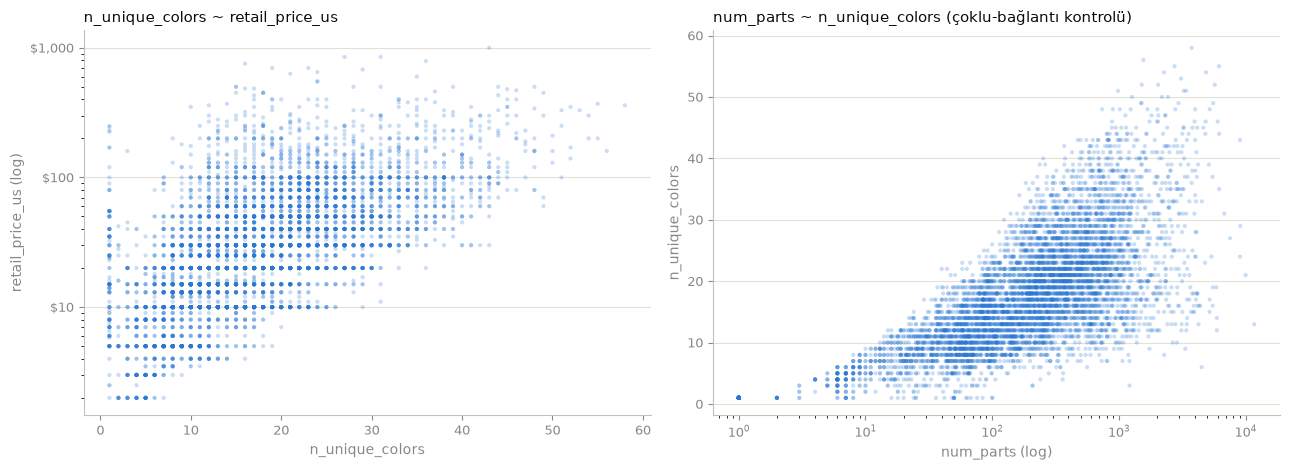

,n_unique_colors ~ fiyat,num_parts ~ n_unique_colors
n,6614.000,6614.000
pearson,0.446,0.461
spearman,0.639,0.709
pearson_log_log,0.560,0.768


In [14]:
colored = df.dropna(subset=["n_unique_colors"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
ax = axes[0]
ax.scatter(colored["n_unique_colors"], colored["retail_price_us"], s=9, color=BLUE, alpha=0.25, edgecolors="none")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(usd)
style_ax(ax, title="n_unique_colors ~ retail_price_us", xlabel="n_unique_colors", ylabel="retail_price_us (log)")

ax = axes[1]
ax.scatter(colored["num_parts"], colored["n_unique_colors"], s=9, color=BLUE, alpha=0.25, edgecolors="none")
ax.set_xscale("log")
style_ax(ax, title="num_parts ~ n_unique_colors (çoklu-bağlantı kontrolü)", xlabel="num_parts (log)", ylabel="n_unique_colors")
fig.tight_layout()
plt.show()

color_corr = correlations(colored["n_unique_colors"], colored["retail_price_us"])
color_parts_corr = correlations(colored["num_parts"], colored["n_unique_colors"])
pd.DataFrame({"n_unique_colors ~ fiyat": color_corr, "num_parts ~ n_unique_colors": color_parts_corr}).round(3)

In [15]:
# Aday sayısal değişkenler arası korelasyon ve VIF (modelde kullanılacak dönüşümlerle: log parça, log1p minifig)
features = pd.DataFrame({
    "log_num_parts": np.log10(colored["num_parts"]),
    "log1p_minifig_count": np.log1p(colored["minifig_count"]),
    "n_unique_colors": colored["n_unique_colors"],
    "year": colored["year"],
})
corr_matrix = features.corr(method="spearman")
vif = pd.Series(np.diag(np.linalg.inv(features.corr().values)), index=features.columns, name="VIF")
print("VIF (>5 dikkat, >10 ciddi çoklu-bağlantı):")
print(vif.round(2).to_string())
print()
print("Spearman korelasyon matrisi:")
corr_matrix.round(3)

VIF (>5 dikkat, >10 ciddi çoklu-bağlantı):
log_num_parts          1.94
log1p_minifig_count    1.70
n_unique_colors        2.93
year                   1.28

Spearman korelasyon matrisi:


,log_num_parts,log1p_minifig_count,n_unique_colors,year
log_num_parts,1.000,0.451,0.709,0.309
log1p_minifig_count,0.451,1.000,0.634,0.115
n_unique_colors,0.709,0.634,1.000,0.423
year,0.309,0.115,0.423,1.000


In [16]:
# Renk, parça sayısının ötesinde bilgi taşıyor mu? Aynı büyüklük dilimi içinde n_unique_colors ~ fiyat
colored = colored.assign(size_tier=pd.cut(colored["num_parts"], bins=size_bins, labels=size_labels))
colored.groupby("size_tier", observed=True).apply(
    lambda g: pd.Series({
        "n": len(g),
        "spearman_renk_fiyat": g["n_unique_colors"].corr(g["retail_price_us"], method="spearman"),
        "spearman_parca_fiyat": g["num_parts"].corr(g["retail_price_us"], method="spearman"),
    }),
    include_groups=False,
).round(3)

,n,spearman_renk_fiyat,spearman_parca_fiyat
size_tier,,,
≤100 parça,2052.0,0.256,0.110
101–500 parça,2822.0,0.436,0.689
>500 parça,1740.0,0.218,0.828


**Bulgu:**
- `n_unique_colors` ~ fiyat: Spearman **0,639** (log-log Pearson 0,560) — orta-güçlü. Ama `num_parts` ile de
  Spearman **0,709**: renk sayısının fiyatla ilişkisinin önemli kısmı "büyük set = çok renk" üzerinden geliyor.
- **Aynı büyüklük dilimi içinde renk hâlâ bilgi taşıyor, özellikle küçük setlerde:** ≤100 parçada renk–fiyat
  korelasyonu (0,256) parça–fiyat korelasyonundan (0,110) **daha güçlü**; 101–500'de 0,436 (parça 0,689); >500'de
  0,218 (parça 0,828). Büyük setlerde renk, parça sayısının gölgesinde kalıyor.
- **Çoklu-bağlantı riski — orta, ciddi değil:** ikili korelasyon yüksek (0,71) ama **VIF'lerin hepsi 5'in altında**
  (en yüksek `n_unique_colors` 2,93). Değişkenler birlikte kullanılabilir; doğrusal modelde **katsayılar ayrı ayrı
  yorumlanırken dikkat** edilmeli. Renk, minifig sayısıyla da ilişkili (0,63) — notebook 07'de minifig parçaları
  dahil edildiği için beklenen bir durum.

## 7. Yıl dağılımı sağlık kontrolü: zamana dayalı train/test bölmesi

In [17]:
def split_report(train_mask, test_mask, name):
    tr, te = df[train_mask], df[test_mask]
    return pd.Series({
        "bölme": name,
        "train_n": len(tr), "test_n": len(te),
        "test_payı_%": round(len(te) / (len(tr) + len(te)) * 100, 1),
        "test_premium_n": int((te["theme_tier"] == "premium").sum()),
        "test_>500_parça_n": int((te["num_parts"] > 500).sum()),
        "train_medyan_$": tr["retail_price_us"].median(), "test_medyan_$": te["retail_price_us"].median(),
    })


y = df["year"]
splits = pd.DataFrame([
    split_report(y.between(2015, 2023), y.between(2024, 2025), "A) 2015–2023 / 2024–2025 (ilk plan)"),
    split_report(y <= 2023, y.between(2024, 2025), "B) tüm yıllar ≤2023 / 2024–2025"),
    split_report(y <= 2022, y.between(2023, 2025), "C) tüm yıllar ≤2022 / 2023–2025"),
    split_report(y.between(2015, 2022), y.between(2023, 2025), "D) 2015–2022 / 2023–2025"),
]).set_index("bölme")
print(f"2015 öncesi set (A ve D bölmelerinde kullanılmıyor): {(y < 2015).sum():,}")
splits

2015 öncesi set (A ve D bölmelerinde kullanılmıyor): 2,266


,train_n,test_n,test_payı_%,test_premium_n,test_>500_parça_n,train_medyan_$,test_medyan_$
bölme,,,,,,,
A) 2015–2023 / 2024–2025 (ilk plan),3462,886,20.4,97,397,29.99,49.99
B) tüm yıllar ≤2023 / 2024–2025,5728,886,13.4,97,397,24.99,49.99
C) tüm yıllar ≤2022 / 2023–2025,5323,1291,19.5,133,561,24.99,44.99
D) 2015–2022 / 2023–2025,3057,1291,29.7,133,561,29.99,44.99


In [18]:
# Test yıllarının segment/büyüklük kompozisyonu train'e benziyor mu?
comp = pd.concat({
    "2015–2023": df[y.between(2015, 2023)]["theme_tier"].value_counts(normalize=True),
    "2024–2025": df[y.between(2024, 2025)]["theme_tier"].value_counts(normalize=True),
}, axis=1).mul(100).round(1)
comp_size = pd.concat({
    "2015–2023": df[y.between(2015, 2023)]["size_tier"].value_counts(normalize=True),
    "2024–2025": df[y.between(2024, 2025)]["size_tier"].value_counts(normalize=True),
}, axis=1).mul(100).round(1)
print("theme_tier payı (%):"); print(comp.to_string()); print()
print("size_tier payı (%):"); print(comp_size.to_string())

theme_tier payı (%):
             2015–2023  2024–2025
theme_tier                       
other             71.2       71.0
mass_market       21.4       18.1
premium            7.5       10.9

size_tier payı (%):
               2015–2023  2024–2025
size_tier                          
101–500 parça       45.7       44.7
>500 parça          27.4       44.8
≤100 parça          26.8       10.5


**Bulgu:**
- **Sayıca yeterli:** 2015–2023 train **3.462**, 2024–2025 test **886** set (%20,4) — klasik 80/20 oranı.
- **Asıl sorun büyüklük değil, kompozisyon kayması:**
  - Test yıllarında **>500 parçalı set payı %44,8** (train %27,4), **≤100 parça payı %10,5** (train %26,8),
    premium %10,9 (train %7,5). Medyan fiyat test'te **$49,99**, train'de $29,99.
  - Model, train'de az gördüğü büyük/pahalı setlere genelleme yapmak zorunda kalır; test hatası "tipik" bir
    setin hatasını temsil etmez. Bu kaymanın LEGO'nun gerçekten büyüyen setlerinden mi, yoksa Brickset
    eşleşmesinin son yıllarda büyük setlere yığılmasından mı geldiği bu veriyle ayırt edilemiyor.
  - Alt gruplar küçük: test'te yalnızca **97 premium** set → segment bazlı metrikler gürültülü olur.
- **Önerilen alternatif:**
  1. **Ana bölme: tüm yıllar ≤2022 / 2023–2025 (C).** Test 1.291 set (%19,5), premium 133, >500 parça 561; train
     2015 öncesindeki 2.266 seti de kullanarak 5.323'e çıkıyor (daha geniş fiyat/büyüklük çeşitliliği). Fiyatlar
     nominal olduğu için yıl değişkeni modelde tutulmalı; §2'deki sabit parça başı fiyat bulgusu bu setlerin
     kullanılabilir olduğunu destekliyor.
  2. **Genişleyen pencereli doğrulama (rolling-origin):** ≤2020→2021, ≤2021→2022, ≤2022→2023, ≤2023→2024–2025.
     Sonucun tek bir test döneminin kompozisyonuna bağlı olup olmadığını gösterir.
  3. Hata metriklerini **`size_tier` bazında ayrıca raporla** — genel metrik büyük setlerin payı değiştikçe kayar.

## Özet — fiyatla ilişki gücü

In [19]:
summary = pd.DataFrame({
    "num_parts": correlations(df["num_parts"], df["retail_price_us"]),
    "minifig_count": correlations(df["minifig_count"], df["retail_price_us"]),
    "n_unique_colors": correlations(df["n_unique_colors"], df["retail_price_us"]),
    "year": correlations(df["year"], df["retail_price_us"]),
}).T[["n", "pearson", "spearman"]]
summary["n"] = summary["n"].astype(int)
summary.sort_values("spearman", ascending=False).round(3)

,n,pearson,spearman
num_parts,6614,0.890,0.846
n_unique_colors,6614,0.446,0.639
minifig_count,6614,0.421,0.414
year,6614,0.195,0.268


**Fiyatla güçlü ilişkili:**
- **`num_parts`** — açık ara en güçlü (Spearman 0,85; log-log doğrusal, eğim 0,53). Modelin omurgası.
- **`n_unique_colors`** — orta-güçlü (Spearman 0,64), ama bunun çoğu parça sayısıyla ortak. Küçük setlerde parça
  sayısının ötesinde bilgi taşıyor. VIF < 3: birlikte kullanılabilir.
- **`theme_tier = premium`** — büyük setlerde belirgin fiyat primi (>500 parça: $139,99 vs $79,99).

**Zayıf / gürültülü:**
- **`minifig_count`** (sayısal) — Spearman 0,41, etkisi büyüklüğe göre yön değiştiriyor; `has_minifig` + etkileşim daha anlamlı.
- **`year`** — Spearman 0,27, etkisi büyük ölçüde set büyüklüğü üzerinden; parça başına nominal fiyat 2015–2025 sabit.
- **`mass_market` vs `other`** — aynı büyüklükte fiyat farkı yok.

**Modelleme için çıkarımlar:**
- Hedef: **log(fiyat)**; ana özellik: **log(num_parts)**.
- 2024–2025 test seti **sayıca yeterli (886) ama train'den sistematik olarak daha büyük/pahalı setlerden oluşuyor.**
  Önerilen: ≤2022 / 2023–2025 bölmesi + genişleyen pencereli doğrulama + `size_tier` bazında metrik raporu.